In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Leer el archivo CSV (ajusta la ruta si es necesario)
file_path = r"/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/DATOS/processed_data.csv"
df = pd.read_csv(file_path,parse_dates=False)


# Convertir columnas de caudal a numérico (coaccionando errores a NaN)
caudal_cols = ['calamar_monthly', 'bolivar_monthly', 'manaos_monthly',
               'obidos_monthly', 'tabatinga_monthly', 'timbues_monthly']

for col in caudal_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ver estructura
df.head()

,year,month,calamar_monthly,bolivar_monthly,manaos_monthly,obidos_monthly,tabatinga_monthly,timbues_monthly
0,2019,12,NaN,22317.741935,NaN,133473.333333,NaN,NaN
1,2019,11,NaN,34645.333333,NaN,111573.333333,NaN,NaN
2,2019,10,NaN,48297.419355,NaN,119045.161290,NaN,NaN
3,2019,9,NaN,69857.333333,NaN,189366.666667,NaN,NaN
4,2019,8,NaN,72203.225806,NaN,236867.741935,NaN,15578.267


In [2]:
import matplotlib.pyplot as plt

def ciclo_anual_estaciones(df, columnas, titulos=None, colores=None, nombre_parametro="Caudal"):
    if titulos is None:
        titulos = columnas

    if colores is None:
        colores = [None] * len(columnas)

    plt.figure(figsize=(10, 5))
    resultados = {}

    year_min_global = None
    year_max_global = None

    for col, titulo, color in zip(columnas, titulos, colores):
        datos = df[['year', 'month', col]].copy()
        datos = datos.dropna(subset=[col])

        if datos.empty:
            print(f"No hay datos para {titulo}")
            continue

        y_min = datos['year'].min()
        y_max = datos['year'].max()

        if year_min_global is None or y_min < year_min_global:
            year_min_global = y_min
        if year_max_global is None or y_max > year_max_global:
            year_max_global = y_max

        ciclo = datos.groupby('month')[col].mean().reset_index()
        ciclo.columns = ['Mes', 'Caudal_promedio']

        caudal_medio = datos[col].mean()

        plt.plot(
            ciclo['Mes'],
            ciclo['Caudal_promedio'],
            linestyle='-',
            linewidth=2,
            label=titulo,
            color=color
        )

        resultados[titulo] = {
            'ciclo': ciclo,
            'media_anual': caudal_medio
        }

        print(f"\n=== {titulo} ===")
        print(f"Caudal medio anual: {caudal_medio:.3f} m³/s")
        print(ciclo.to_string(index=False))

    # 🔹 título
    plt.title(
        f'Ciclo anual de {nombre_parametro}\n'
        f'(Período con datos: {year_min_global} a {year_max_global})',
        fontsize=18
    )

    plt.xlabel('Mes', fontsize=18)
    plt.ylabel(f'{nombre_parametro} promedio (m³/s)', fontsize=18)

    plt.xticks(
        range(1,13),
        ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'],
        fontsize=18
    )
    plt.yticks(fontsize=18)

    plt.grid(True, linestyle='--', alpha=0.6)

    plt.legend(fontsize=18)

    plt.show()

    return resultados


=== Calamar ===
Caudal medio anual: 7265.039 m³/s
 Mes  Caudal_promedio
   1      7004.967742
   2      4509.429107
   3      4148.869307
   4      4975.838557
   5      6896.278286
   6      8187.345771
   7      8002.861796
   8      7420.308528
   9      7615.814677
  10      8594.451124
  11      9919.576243
  12      9904.730016


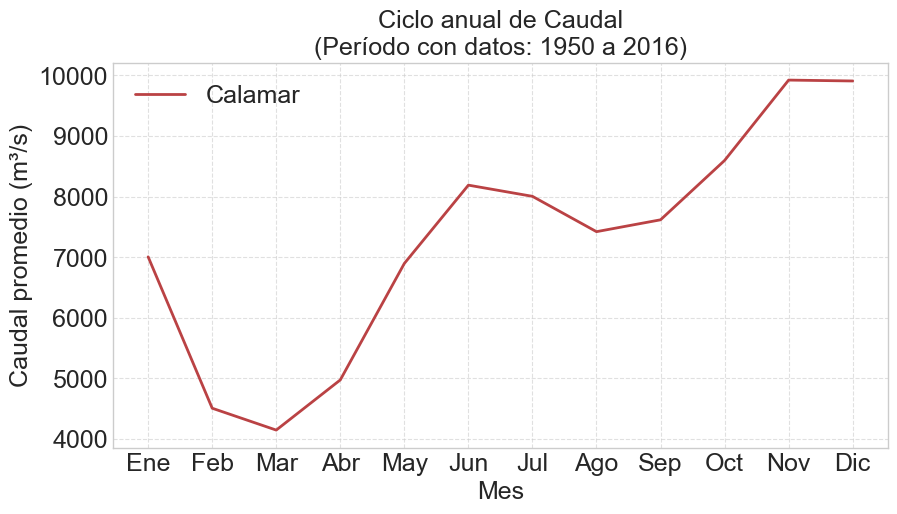

{'Calamar': {'ciclo':     Mes  Caudal_promedio
  0     1      7004.967742
  1     2      4509.429107
  2     3      4148.869307
  3     4      4975.838557
  4     5      6896.278286
  5     6      8187.345771
  6     7      8002.861796
  7     8      7420.308528
  8     9      7615.814677
  9    10      8594.451124
  10   11      9919.576243
  11   12      9904.730016,
  'media_anual': np.float64(7265.0392627493275)}}

In [3]:
ciclo_anual_estaciones(
    df,
    columnas=['calamar_monthly'],
    titulos=['Calamar'],
    colores=['#ba4244']
)


=== Bolívar ===
Caudal medio anual: 33910.335 m³/s
 Mes  Caudal_promedio
   1     12740.353131
   2      7584.906331
   3      6055.017078
   4      9083.545098
   5     24194.428843
   6     40941.149020
   7     58698.908918
   8     71141.557875
   9     67217.494118
  10     49332.929791
  11     35521.515686
  12     24412.217300


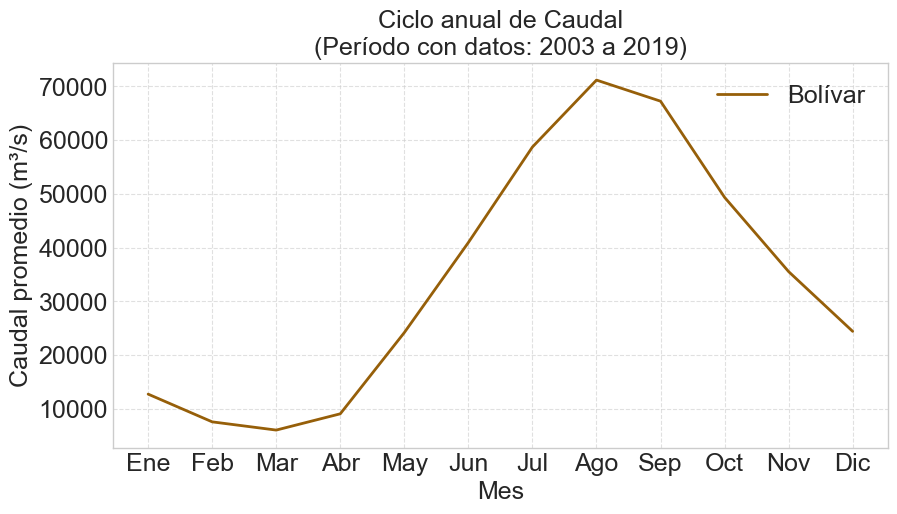

{'Bolívar': {'ciclo':     Mes  Caudal_promedio
  0     1     12740.353131
  1     2      7584.906331
  2     3      6055.017078
  3     4      9083.545098
  4     5     24194.428843
  5     6     40941.149020
  6     7     58698.908918
  7     8     71141.557875
  8     9     67217.494118
  9    10     49332.929791
  10   11     35521.515686
  11   12     24412.217300,
  'media_anual': np.float64(33910.33526575072)}}

In [4]:
ciclo_anual_estaciones(
    df,
    columnas=['bolivar_monthly'],
    titulos=['Bolívar'],
    colores=['#965f09']
)


=== Tabatinga ===
Caudal medio anual: 36266.535 m³/s
 Mes  Caudal_promedio
   1     38133.740192
   2     40970.579594
   3     45399.529207
   4     49549.792793
   5     50653.884853
   6     43817.424821
   7     33542.652235
   8     24245.196164
   9     20967.622909
  10     23792.972839
  11     29532.801802
  12     34665.841325

=== Manaos ===
Caudal medio anual: 104443.026 m³/s
 Mes  Caudal_promedio
   1     92010.143369
   2     99894.117406
   3    110824.759953
   4    125734.326145
   5    136481.698432
   6    141061.122685
   7    135875.544355
   8    115274.485633
   9     84570.885180
  10     63903.177843
  11     66696.600000
  12     79541.568002

=== Óbidos ===
Caudal medio anual: 175057.198 m³/s
 Mes  Caudal_promedio
   1    141591.081594
   2    165397.560629
   3    191272.642680
   4    216693.717949
   5    235180.645161
   6    237578.910256
   7    225448.697270
   8    197358.250620
   9    154419.057692
  10    113940.366005
  11    103793.038462
  12  

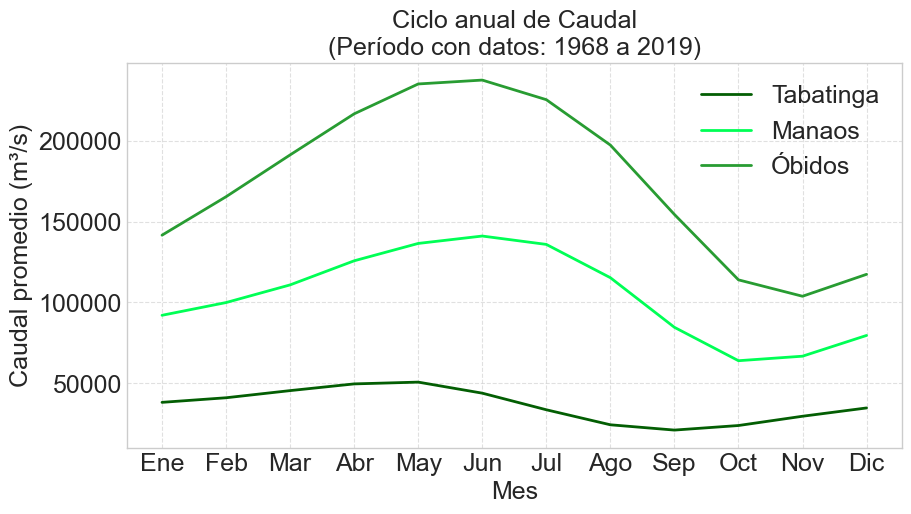

{'Tabatinga': {'ciclo':     Mes  Caudal_promedio
  0     1     38133.740192
  1     2     40970.579594
  2     3     45399.529207
  3     4     49549.792793
  4     5     50653.884853
  5     6     43817.424821
  6     7     33542.652235
  7     8     24245.196164
  8     9     20967.622909
  9    10     23792.972839
  10   11     29532.801802
  11   12     34665.841325,
  'media_anual': np.float64(36266.53502329207)},
 'Manaos': {'ciclo':     Mes  Caudal_promedio
  0     1     92010.143369
  1     2     99894.117406
  2     3    110824.759953
  3     4    125734.326145
  4     5    136481.698432
  5     6    141061.122685
  6     7    135875.544355
  7     8    115274.485633
  8     9     84570.885180
  9    10     63903.177843
  10   11     66696.600000
  11   12     79541.568002,
  'media_anual': np.float64(104443.02620164576)},
 'Óbidos': {'ciclo':     Mes  Caudal_promedio
  0     1    141591.081594
  1     2    165397.560629
  2     3    191272.642680
  3     4    216693.717949
  

In [5]:
ciclo_anual_estaciones(
    df,
    columnas=['tabatinga_monthly', 'manaos_monthly', 'obidos_monthly'],
    titulos=['Tabatinga', 'Manaos', 'Óbidos'],
    colores=['#035e03', '#00ff55', '#289c32']
)


=== Timbúes ===
Caudal medio anual: 15718.038 m³/s
 Mes  Caudal_promedio
   1     15538.596446
   2     17019.561615
   3     18114.261969
   4     18304.314939
   5     17449.199816
   6     16580.724120
   7     15847.392219
   8     14171.451881
   9     12964.719152
  10     13522.911984
  11     14403.149282
  12     14622.740095


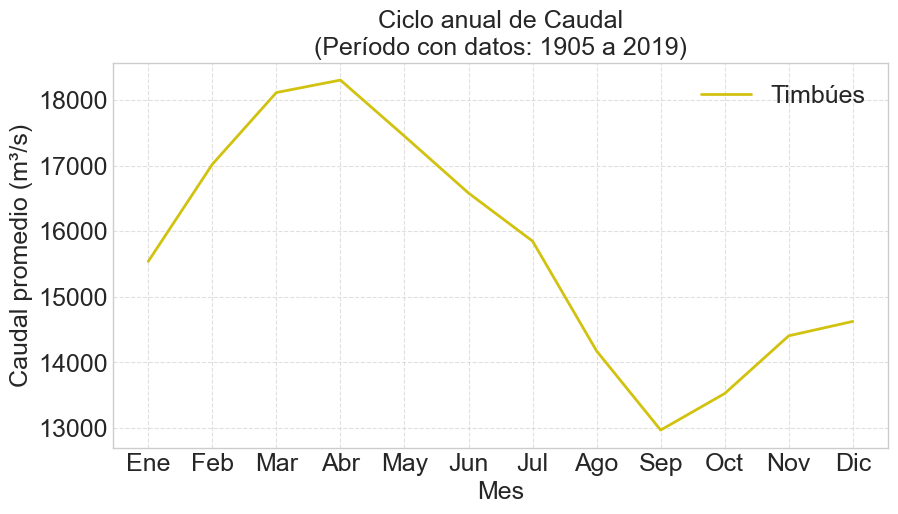

{'Timbúes': {'ciclo':     Mes  Caudal_promedio
  0     1     15538.596446
  1     2     17019.561615
  2     3     18114.261969
  3     4     18304.314939
  4     5     17449.199816
  5     6     16580.724120
  6     7     15847.392219
  7     8     14171.451881
  8     9     12964.719152
  9    10     13522.911984
  10   11     14403.149282
  11   12     14622.740095,
  'media_anual': np.float64(15718.03835071491)}}

In [6]:
ciclo_anual_estaciones(
    df,
    columnas=['timbues_monthly'],
    titulos=['Timbúes'],
    colores=['#d2c210']
)

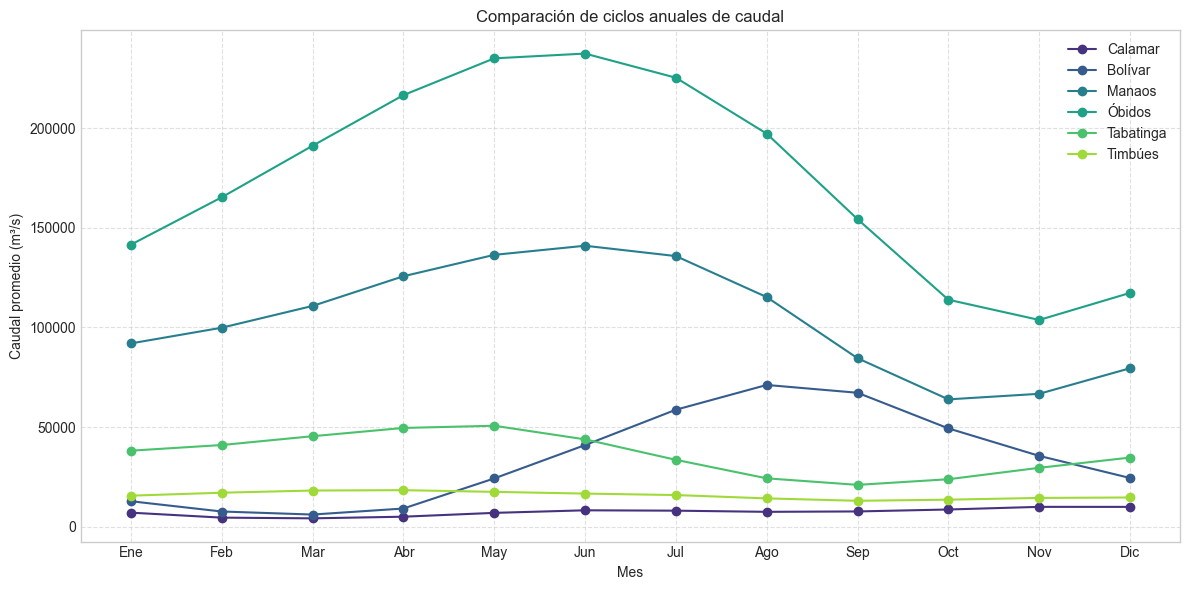

In [7]:
# Juntar todos los ciclos en un DataFrame para comparar
ciclos = {}
for col, nombre in zip(caudal_cols, ['Calamar','Bolívar','Manaos','Óbidos','Tabatinga','Timbúes']):
    datos = df[['year', 'month', col]].dropna(subset=[col])
    if not datos.empty:
        ciclo = datos.groupby('month')[col].mean()
        ciclos[nombre] = ciclo

df_ciclos = pd.DataFrame(ciclos)
df_ciclos.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Graficar
plt.figure(figsize=(12, 6))
for col in df_ciclos.columns:
    plt.plot(df_ciclos.index, df_ciclos[col], marker='o', label=col)
plt.title('Comparación de ciclos anuales de caudal')
plt.xlabel('Mes')
plt.ylabel('Caudal promedio (m³/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [30]:
def distribucion_estaciones_bootstrap(
    df,
    columnas,
    titulos=None,
    colores=None,
    log_transform=False,
    bins=22,
    n_boot=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as ticker
    from scipy.stats import norm, gamma, logistic, skew

    if titulos is None:
        titulos = columnas

    if colores is None:
        colores = sns.color_palette("viridis", len(columnas))

    for col, titulo, color in zip(columnas, titulos, colores):

        # ==============================
        # DATA
        # ==============================
        data = df[col].dropna().values
        data = data[np.isfinite(data)]

        if log_transform:
            data = data[data > 0]
            data = np.log10(data)
            xlabel = rf'$log_{{10}}({titulo})$'
        else:
            xlabel = titulo

        n = len(data)

        # ==============================
        # BOOTSTRAP
        # ==============================
        means, vars_, skews = [], [], []
        AICs = {"Normal": [], "Gamma": [], "Logística": []}

        for _ in range(n_boot):
            sample = np.random.choice(data, size=n, replace=True)

            means.append(np.mean(sample))
            vars_.append(np.var(sample))
            skews.append(skew(sample))

            # Normal
            p = norm.fit(sample)
            logL = np.sum(norm.logpdf(sample, *p))
            AICs["Normal"].append(2*2 - 2*logL)

            # Gamma
            p = gamma.fit(sample)
            logL = np.sum(gamma.logpdf(sample, *p))
            AICs["Gamma"].append(2*3 - 2*logL)

            # Logistic
            p = logistic.fit(sample)
            logL = np.sum(logistic.logpdf(sample, *p))
            AICs["Logística"].append(2*2 - 2*logL)

        # ==============================
        # RESULTADOS BOOTSTRAP
        # ==============================
        mean = np.mean(means)
        var = np.mean(vars_)
        skewness = np.mean(skews)

        mean_ci = np.percentile(means, [2.5, 97.5])
        var_ci = np.percentile(vars_, [2.5, 97.5])
        skew_ci = np.percentile(skews, [2.5, 97.5])

        avg_AIC = {k: np.mean(v) for k, v in AICs.items()}
        best_name = min(avg_AIC, key=avg_AIC.get)

        # ==============================
        # AJUSTE FINAL
        # ==============================
        if best_name == "Normal":
            params = norm.fit(data)
            dist = norm
        elif best_name == "Gamma":
            params = gamma.fit(data)
            dist = gamma
        else:
            params = logistic.fit(data)
            dist = logistic

        x = np.linspace(data.min(), data.max(), 1000)
        pdf = dist.pdf(x, *params)

        # ==============================
        # PLOT
        # ==============================
        fig, ax = plt.subplots(figsize=(6, 4))

        sns.histplot(
            data,
            bins=bins,
            stat="density",
            color=color,
            alpha=0.6,
            ax=ax
        )

        ax.plot(x, pdf, color=color, linewidth=2.5,
                label=f"{best_name}")

        # TEXTO
        textstr = (
            f"μ = {mean:.2f} [{mean_ci[0]:.2f}, {mean_ci[1]:.2f}]\n"
            f"σ² = {var:.2f} [{var_ci[0]:.2f}, {var_ci[1]:.2f}]\n"
            f"sk = {skewness:.2f} [{skew_ci[0]:.2f}, {skew_ci[1]:.2f}]"
        )

        ax.text(
            0.97, 0.97, textstr,
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
        )

        ax.set_title(titulo)
        ax.set_xlabel(r"$m^{3}/s$")
        ax.set_ylabel("PDF")

        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(False)
        ax.legend()

        plt.tight_layout()
        plt.show()

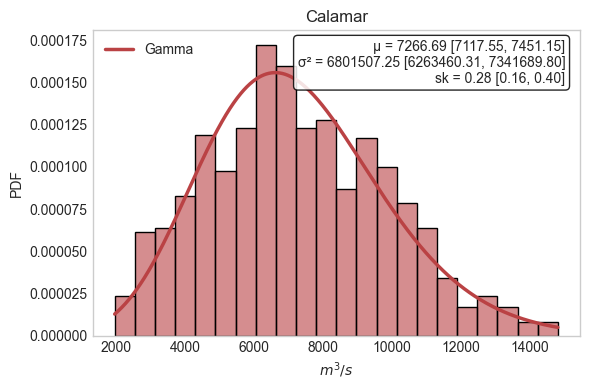

In [31]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['calamar_monthly'],
    titulos=['Calamar'],
    colores=['#ba4244']
)

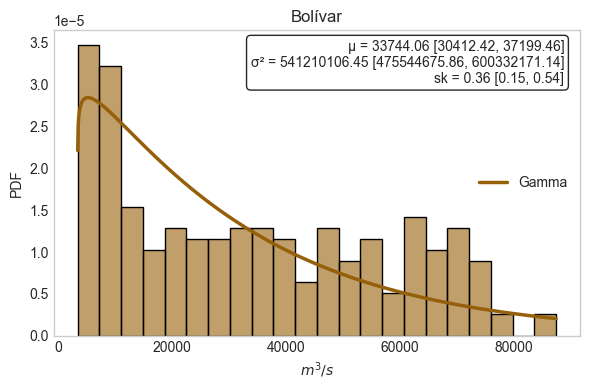

In [32]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['bolivar_monthly'],
    titulos=['Bolívar'],
    colores=['#965f09']
)

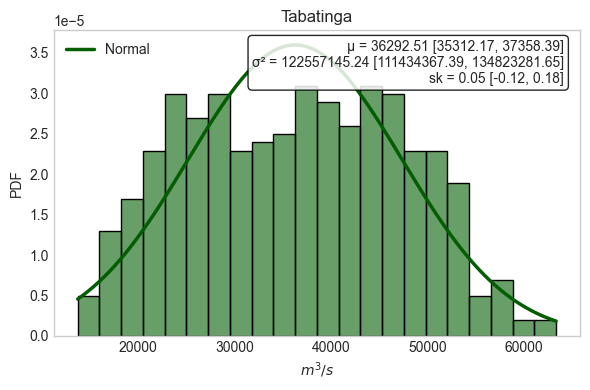

In [33]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['tabatinga_monthly'],
    titulos=['Tabatinga'],
    colores=['#035e03']
)

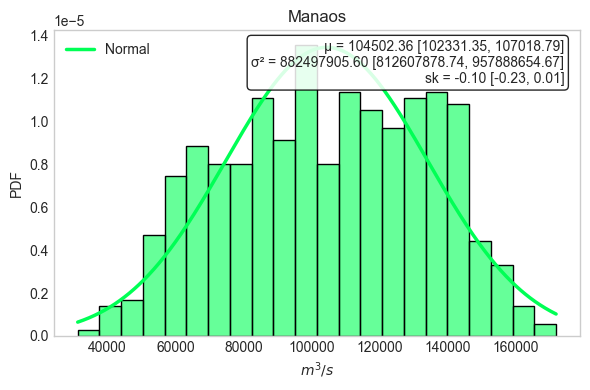

In [34]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['manaos_monthly'],
    titulos=['Manaos'],
    colores=['#00ff55']
)

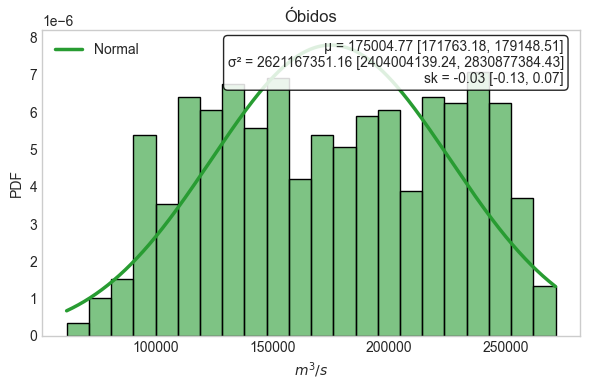

In [35]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['obidos_monthly'],
    titulos=['Óbidos'],
    colores=['#289c32']
)

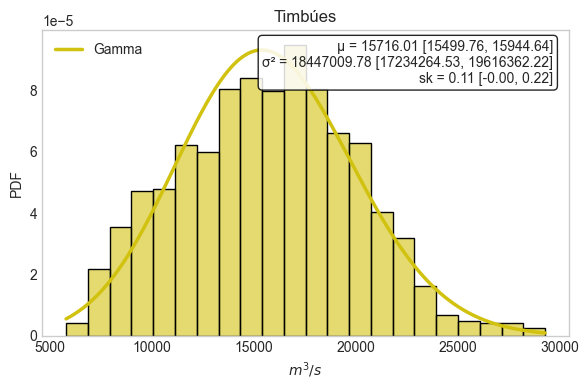

In [36]:
distribucion_estaciones_bootstrap(
    df,
    columnas=['timbues_monthly'],
    titulos=['Timbúes'],
    colores=['#d2c210']
)

In [37]:
def distribuciones_estaciones_bootstrap(
    df,
    columnas,
    titulos=None,
    colores=None,
    log_transform=False,
    bins=22,
    n_boot=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as ticker
    from scipy.stats import norm, gamma, logistic, skew

    if titulos is None:
        titulos = columnas

    if colores is None:
        colores = sns.color_palette("viridis", len(columnas))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(7, 5))

    for col, titulo, color in zip(columnas, titulos, colores):

        data = df[col].dropna().values
        data = data[np.isfinite(data)]

        if log_transform:
            data = data[data > 0]
            data = np.log10(data)
            xlabel = rf'$log_{{10}}({titulo})$'
        else:
            xlabel = "Valor"

        n = len(data)

        # bootstrap
        AICs = {"Normal": [], "Gamma": [], "Logística": []}

        for _ in range(n_boot):
            sample = np.random.choice(data, size=n, replace=True)

            p = norm.fit(sample)
            AICs["Normal"].append(2*2 - 2*np.sum(norm.logpdf(sample, *p)))

            p = gamma.fit(sample)
            AICs["Gamma"].append(2*3 - 2*np.sum(gamma.logpdf(sample, *p)))

            p = logistic.fit(sample)
            AICs["Logística"].append(2*2 - 2*np.sum(logistic.logpdf(sample, *p)))

        avg_AIC = {k: np.mean(v) for k, v in AICs.items()}
        best_name = min(avg_AIC, key=avg_AIC.get)

        if best_name == "Normal":
            params = norm.fit(data)
            dist = norm
        elif best_name == "Gamma":
            params = gamma.fit(data)
            dist = gamma
        else:
            params = logistic.fit(data)
            dist = logistic

        x = np.linspace(data.min(), data.max(), 1000)
        pdf = dist.pdf(x, *params)

        sns.histplot(
            data,
            bins=bins,
            stat="density",
            color=color,
            alpha=0.25,
            ax=ax
        )

        ax.plot(x, pdf, color=color, linewidth=2.5,
                label=f"{titulo} ({best_name})")

    ax.set_xlabel(r"$m^{3}/s$")
    ax.set_ylabel("PDF")

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

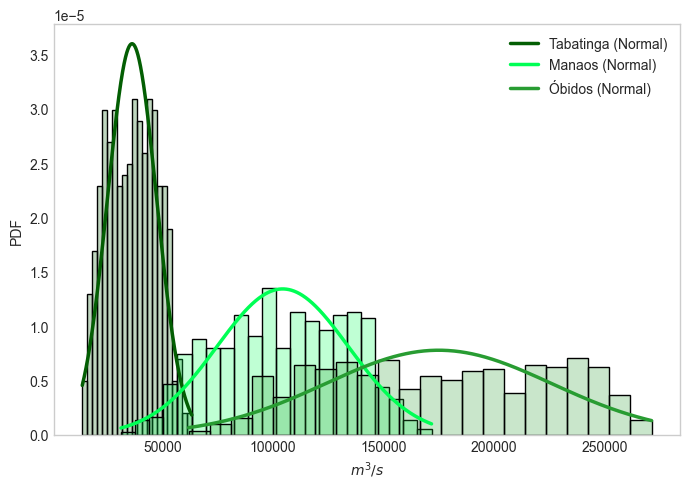

In [38]:
distribuciones_estaciones_bootstrap(
    df,
    columnas=['tabatinga_monthly', 'manaos_monthly', 'obidos_monthly'],
    titulos=['Tabatinga', 'Manaos', 'Óbidos'],
    colores=['#035e03', '#00ff55', '#289c32']
)